In [1]:
!pip install SimpleITK

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 14.7 MB/s eta 0:00:00


In [ ]:
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
import SimpleITK as sitk
import numpy as np

# 🔹 Load .mhd scan
def load_mhd(path):
    image = sitk.ReadImage(path)
    scan = sitk.GetArrayFromImage(image)
    return scan


# 🔹 Convert world coordinate (Z) → voxel index
def world_to_voxel(coordZ, origin, spacing):
    origin_z = origin[2]
    spacing_z = spacing[2]

    voxel_z = int((coordZ - origin_z) / spacing_z)
    return voxel_z


# 🔹 Get malignant slice indices
def get_nodule_slices(scan_id, annotations, origin, spacing, scan):

    nodules = annotations[annotations["seriesuid"] == scan_id]

    malignant_slices = set()

    for _, row in nodules.iterrows():
        z = row["coordZ"]

        slice_idx = world_to_voxel(z, origin, spacing)

        # include nearby slices for better coverage
        for offset in range(-2, 3):
            idx = slice_idx + offset
            if 0 <= idx < scan.shape[0]:
                malignant_slices.add(idx)

    return malignant_slices

In [3]:
import cv2
import os
import numpy as np

def save_labeled_slices(scan, malignant_slices, scan_id, base_folder):

    for i in range(scan.shape[0]):

        slice_img = scan[i]

        # 🔹 Skip useless slices
        #if not is_useful(slice_img):
            #continue

        # Normalize
        norm = cv2.normalize(slice_img, None, 0, 255, cv2.NORM_MINMAX)
        norm = norm.astype(np.uint8)

        # Label
        if i in malignant_slices:
            label = "malignant"
        else:
            label = "benign"

        folder = os.path.join(base_folder, label)
        os.makedirs(folder, exist_ok=True)

        filename = f"{scan_id}_slice_{i}.png"

        cv2.imwrite(os.path.join(folder, filename), norm)

In [4]:
import pandas as pd

annotations = pd.read_csv("/content/drive/MyDrive/dataset_file/annotations.csv")
annotations.head()

,seriesuid,coordX,coordY,coordZ,diameter_mm
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.699421,-175.319272,-298.387506,5.651471
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.783651,-211.925149,-227.121250,4.224708
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,69.639017,-140.944586,876.374496,5.786348
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-24.013824,192.102405,-391.081276,8.143262
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.441547,172.464881,-405.493732,18.545150


In [5]:
import os

dataset_path = "/content/drive/MyDrive/dataset_file/seg-lungs-LUNA16/seg-lungs-LUNA16"

mhd_files = [f for f in os.listdir(dataset_path) if f.endswith(".mhd")]

NUM_SCANS = 50 # start small
selected_files = mhd_files[:NUM_SCANS]

print("Total scans to process:", len(selected_files))

Total scans to process: 50


In [6]:
import shutil
shutil.rmtree("/content/dataset", ignore_errors=True)

In [7]:
import SimpleITK as sitk

for file in selected_files:

    print("\nProcessing:", file)

    path = os.path.join(dataset_path, file)

    # 🔹 Load scan
    image = sitk.ReadImage(path)
    scan = sitk.GetArrayFromImage(image)

    # 🔹 Metadata
    origin = image.GetOrigin()
    spacing = image.GetSpacing()

    # 🔹 Scan ID
    scan_id = file.replace(".mhd", "")

    print("Shape:", scan.shape)

    # 🔹 Get malignant slices
    malignant_slices = get_nodule_slices(
        scan_id, annotations, origin, spacing, scan
    )

    print("Malignant slices:", len(malignant_slices))

    # 🔥 ADD THIS LINE RIGHT HERE
    save_labeled_slices(
        scan,
        malignant_slices,
        scan_id,
        "/content/dataset"
    )

    # 🔹 Free memory
    del scan


Processing: 1.3.6.1.4.1.14519.5.2.1.6279.6001.239358021703233250639913775427.mhd
Shape: (133, 512, 512)
Malignant slices: 14

Processing: 1.3.6.1.4.1.14519.5.2.1.6279.6001.232071262560365924176679652948.mhd
Shape: (263, 512, 512)
Malignant slices: 5

Processing: 1.3.6.1.4.1.14519.5.2.1.6279.6001.241717018262666382493757419144.mhd
Shape: (257, 512, 512)
Malignant slices: 10

Processing: 1.3.6.1.4.1.14519.5.2.1.6279.6001.231645134739451754302647733304.mhd
Shape: (255, 512, 512)
Malignant slices: 0

Processing: 1.3.6.1.4.1.14519.5.2.1.6279.6001.232011770495640253949434620907.mhd
Shape: (166, 512, 512)
Malignant slices: 0

Processing: 1.3.6.1.4.1.14519.5.2.1.6279.6001.241083615484551649610616348856.mhd
Shape: (159, 512, 512)
Malignant slices: 5

Processing: 1.3.6.1.4.1.14519.5.2.1.6279.6001.237915456403882324748189195892.mhd
Shape: (122, 512, 512)
Malignant slices: 0

Processing: 1.3.6.1.4.1.14519.5.2.1.6279.6001.231834776365874788440767645596.mhd
Shape: (519, 512, 512)
Malignant slices: 

In [8]:
print("Benign:", len(os.listdir("/content/dataset/benign")))
print("Malignant:", len(os.listdir("/content/dataset/malignant")))

Benign: 13149
Malignant: 268


Inbalance in the data

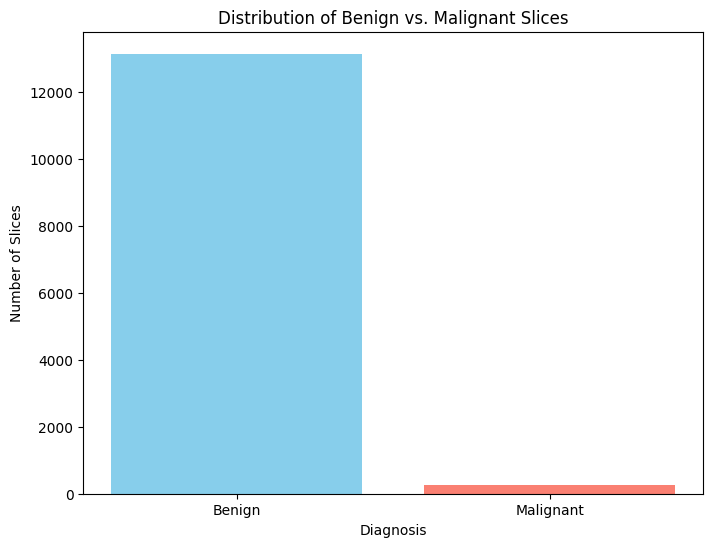

In [9]:
import matplotlib.pyplot as plt
import os

# Get counts from the dataset directory
benign_count = len(os.listdir("/content/dataset/benign"))
malignant_count = len(os.listdir("/content/dataset/malignant"))

labels = ['Benign', 'Malignant']
counts = [benign_count, malignant_count]

plt.figure(figsize=(8, 6))
plt.bar(labels, counts, color=['skyblue', 'salmon'])
plt.xlabel('Diagnosis')
plt.ylabel('Number of Slices')
plt.title('Distribution of Benign vs. Malignant Slices')
plt.show()

Handling the inbalance in data

In [10]:
import os
import random
import shutil

benign_dir = "/content/dataset/benign"
malignant_dir = "/content/dataset/malignant"

balanced_dir = "/content/balanced_dataset"

# create folders
os.makedirs(f"{balanced_dir}/benign", exist_ok=True)
os.makedirs(f"{balanced_dir}/malignant", exist_ok=True)

# get files
benign_files = os.listdir(benign_dir)
malignant_files = os.listdir(malignant_dir)

# sample benign
benign_sample = random.sample(benign_files, len(malignant_files))

# copy benign
for f in benign_sample:
    shutil.copy(os.path.join(benign_dir, f),
                os.path.join(f"{balanced_dir}/benign", f))

# copy malignant
for f in malignant_files:
    shutil.copy(os.path.join(malignant_dir, f),
                os.path.join(f"{balanced_dir}/malignant", f))

print("Balanced dataset created!")

Balanced dataset created!


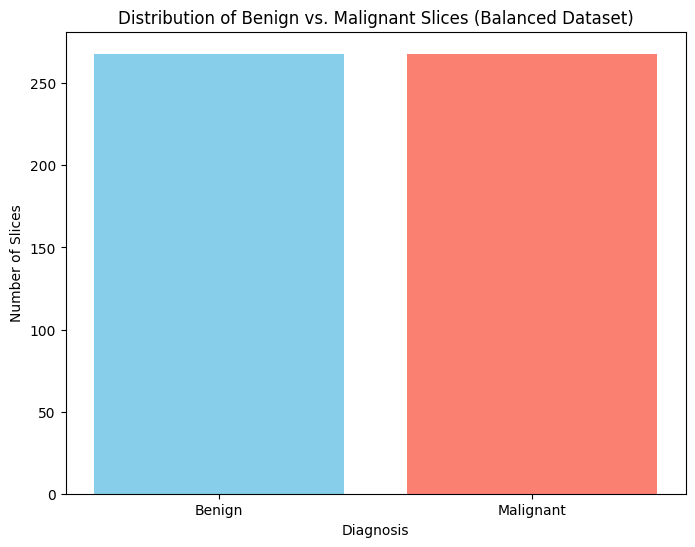

Benign slices in balanced dataset: 268
Malignant slices in balanced dataset: 268


In [11]:
import matplotlib.pyplot as plt
import os

# Get counts from the balanced dataset directory
benign_count_balanced = len(os.listdir("/content/balanced_dataset/benign"))
malignant_count_balanced = len(os.listdir("/content/balanced_dataset/malignant"))

labels_balanced = ['Benign', 'Malignant']
counts_balanced = [benign_count_balanced, malignant_count_balanced]

plt.figure(figsize=(8, 6))
plt.bar(labels_balanced, counts_balanced, color=['skyblue', 'salmon'])
plt.xlabel('Diagnosis')
plt.ylabel('Number of Slices')
plt.title('Distribution of Benign vs. Malignant Slices (Balanced Dataset)')
plt.show()

print(f"Benign slices in balanced dataset: {benign_count_balanced}")
print(f"Malignant slices in balanced dataset: {malignant_count_balanced}")

stopped here

Model inbalance


In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = "/content/balanced_dataset"

img_size = (224, 224)
batch_size = 16

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 430 images belonging to 2 classes.
Found 106 images belonging to 2 classes.


Found 430 images belonging to 2 classes.
Found 106 images belonging to 2 classes.


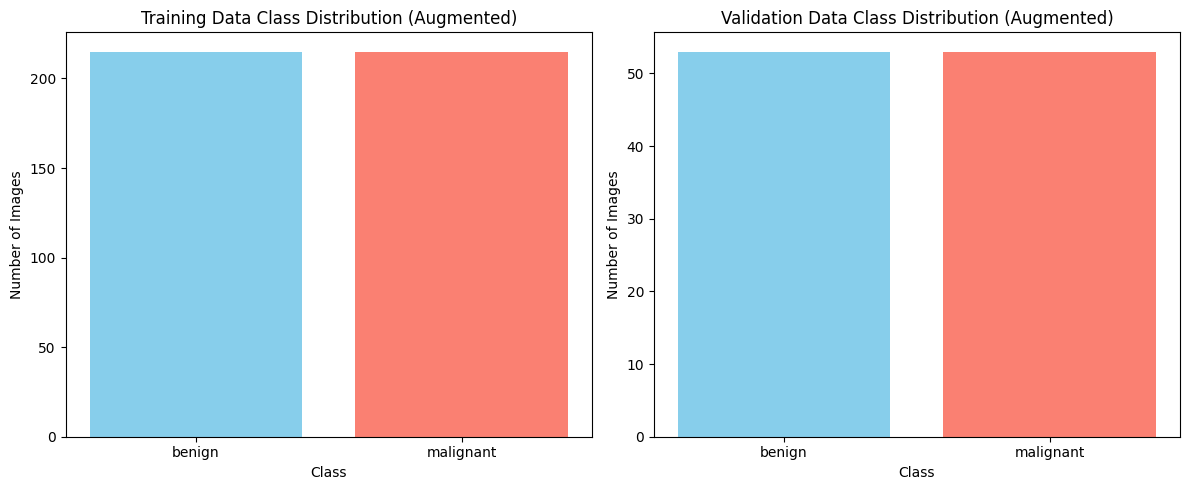

Training data class counts: {'benign': np.int64(215), 'malignant': np.int64(215)}
Validation data class counts: {'benign': np.int64(53), 'malignant': np.int64(53)}


In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Re-create train_data and val_data using the augmented datagen
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)


# Get class names and their indices from the training data generator
class_labels = list(train_data.class_indices.keys())

# Get counts for training data
train_class_counts = np.bincount(train_data.classes)

# Get counts for validation data
val_class_counts = np.bincount(val_data.classes)

# Plotting training data distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(class_labels, train_class_counts, color=['skyblue', 'salmon'])
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Training Data Class Distribution (Augmented)')

# Plotting validation data distribution
plt.subplot(1, 2, 2)
plt.bar(class_labels, val_class_counts, color=['skyblue', 'salmon'])
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Validation Data Class Distribution (Augmented)')

plt.tight_layout()
plt.show()

print(f"Training data class counts: {dict(zip(class_labels, train_class_counts))}")
print(f"Validation data class counts: {dict(zip(class_labels, val_class_counts))}")

In [14]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [16]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

In [17]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
)

Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 20s 510ms/step - accuracy: 0.5744 - loss: 0.7507 - val_accuracy: 0.7358 - val_loss: 0.6187
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 251ms/step - accuracy: 0.6395 - loss: 0.6528 - val_accuracy: 0.7170 - val_loss: 0.6014
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 322ms/step - accuracy: 0.6535 - loss: 0.6034 - val_accuracy: 0.7830 - val_loss: 0.5384
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 248ms/step - accuracy: 0.6791 - loss: 0.5810 - val_accuracy: 0.7453 - val_loss: 0.5156
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 326ms/step - accuracy: 0.7256 - loss: 0.5493 - val_accuracy: 0.6981 - val_loss: 0.5501
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 252ms/step - accuracy: 0.7512 - loss: 0.4949 - val_accuracy: 0.7547 - val_loss: 0.5451
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 328ms/step - accuracy: 0.7395 - loss: 0.5104 - val_accuracy: 0.7547 - val_loss: 0.5116
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 248ms/step - accuracy: 0.7837 - loss: 0.4499 - val_accuracy: 0

In [18]:
loss, acc = model.evaluate(val_data)
print("Validation Accuracy:", acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step - accuracy: 0.7170 - loss: 0.5208
Validation Accuracy: 0.7169811129570007


Adding Confusion Matrix

In [19]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions
preds = model.predict(val_data)
preds = (preds > 0.5).astype(int)

# True labels
true_labels = val_data.classes

# Confusion matrix
cm = confusion_matrix(true_labels, preds)

print(cm)

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 337ms/step
[[22 31]
 [16 37]]


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step


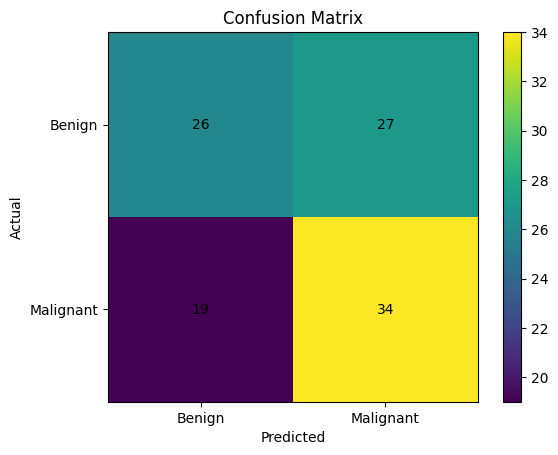

Confusion Matrix:
 [[26 27]
 [19 34]]


In [20]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(val_data)
y_pred = (y_pred > 0.5).astype(int)

y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred)

# Plot with numbers
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

classes = ["Benign", "Malignant"]
plt.xticks([0,1], classes)
plt.yticks([0,1], classes)

# 🔥 ADD NUMBERS INSIDE
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha='center', va='center')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ALSO PRINT RAW VALUES
print("Confusion Matrix:\n", cm)

In [21]:
print(classification_report(true_labels, preds))

              precision    recall  f1-score   support

           0       0.58      0.42      0.48        53
           1       0.54      0.70      0.61        53

    accuracy                           0.56       106
   macro avg       0.56      0.56      0.55       106
weighted avg       0.56      0.56      0.55       106



7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step


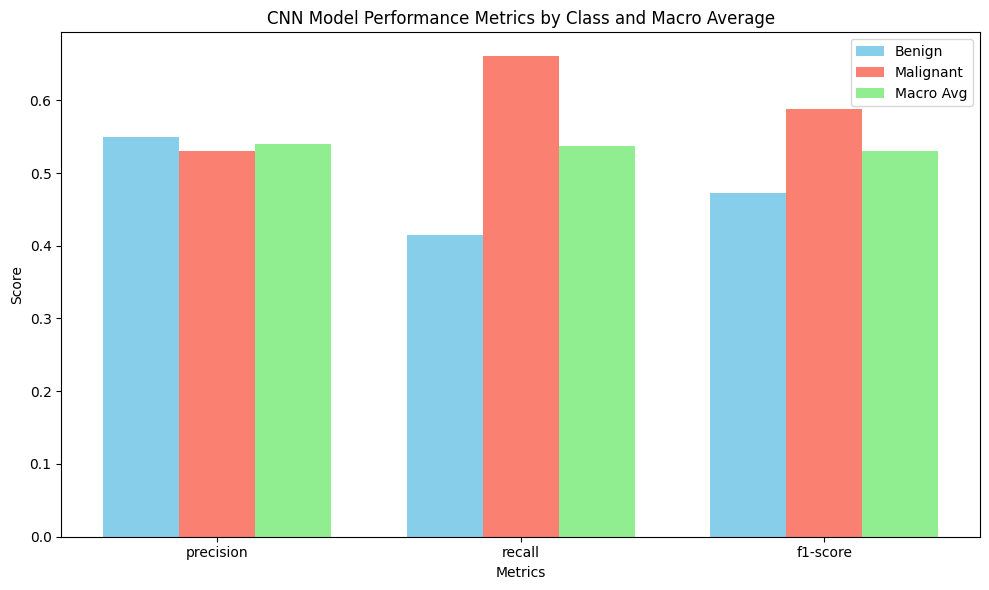

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

# Get predictions from the CNN model
preds_cnn = model.predict(val_data)
preds_cnn = (preds_cnn > 0.5).astype(int)

# Get true labels (already available from val_data)
true_labels_cnn = val_data.classes

# Generate classification report as a dictionary
report_cnn = classification_report(true_labels_cnn, preds_cnn, output_dict=True, zero_division=0)

# Extract metrics for plotting
metrics = ['precision', 'recall', 'f1-score']

# Assuming classes are 'benign' and 'malignant' corresponding to 0 and 1
benign_metrics_cnn = [report_cnn['0'][metric] for metric in metrics]
malignant_metrics_cnn = [report_cnn['1'][metric] for metric in metrics]
macro_avg_metrics_cnn = [report_cnn['macro avg'][metric] for metric in metrics]

# Plotting
x = np.arange(len(metrics))  # the label locations
width = 0.25  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width, benign_metrics_cnn, width, label='Benign', color='skyblue')
rects2 = ax.bar(x, malignant_metrics_cnn, width, label='Malignant', color='salmon')
rects3 = ax.bar(x + width, macro_avg_metrics_cnn, width, label='Macro Avg', color='lightgreen')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('CNN Model Performance Metrics by Class and Macro Average')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

fig.tight_layout()
plt.show()

Using ResNet(Transfer learning)

In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = "/content/balanced_dataset"

img_size = (224, 224)
batch_size = 16

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 430 images belonging to 2 classes.
Found 106 images belonging to 2 classes.


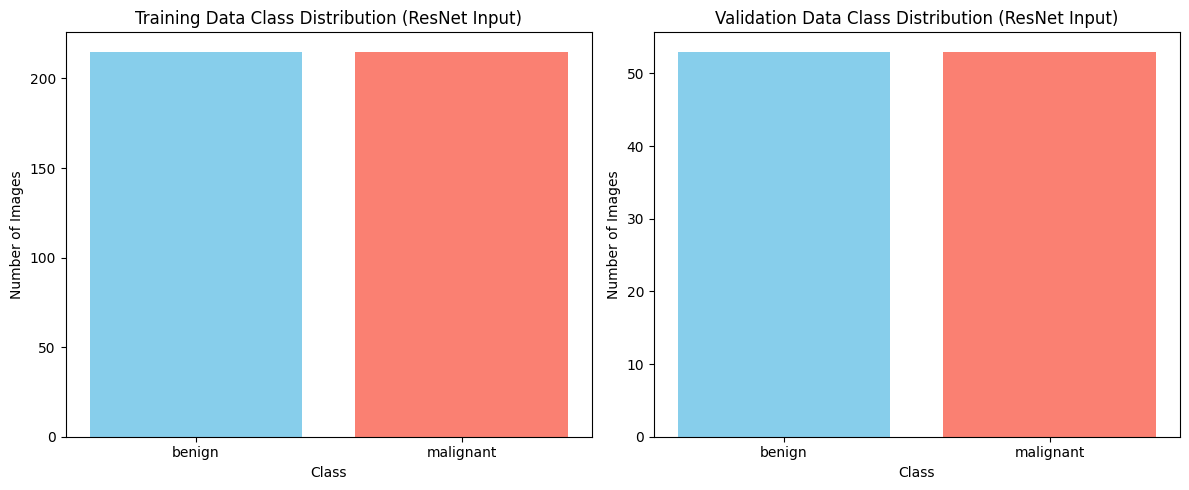

Training data class counts: {'benign': np.int64(215), 'malignant': np.int64(215)}
Validation data class counts: {'benign': np.int64(53), 'malignant': np.int64(53)}


In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Get class names and their indices from the training data generator
class_labels = list(train_data.class_indices.keys())

# Get counts for training data
train_class_counts = np.bincount(train_data.classes)

# Get counts for validation data
val_class_counts = np.bincount(val_data.classes)

# Plotting training data distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(class_labels, train_class_counts, color=['skyblue', 'salmon'])
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Training Data Class Distribution (ResNet Input)')

# Plotting validation data distribution
plt.subplot(1, 2, 2)
plt.bar(class_labels, val_class_counts, color=['skyblue', 'salmon'])
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Validation Data Class Distribution (ResNet Input)')

plt.tight_layout()
plt.show()

print(f"Training data class counts: {dict(zip(class_labels, train_class_counts))}")
print(f"Validation data class counts: {dict(zip(class_labels, val_class_counts))}")

In [25]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base layers
#for layer in base_model.layers:
    #layer.trainable = False

# Unfreeze last 30 layers
for layer in base_model.layers[-30:]:
    layer.trainable = True

# Custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model_resnet = Model(inputs=base_model.input, outputs=output)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Compiling the Module

In [26]:
model_resnet.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Setting the class Weight

In [27]:
class_weight = {
    0: 1.0,
    1: 15.0
}

In [28]:
history_resnet = model_resnet.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
)

Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.6395 - loss: 0.6188 - val_accuracy: 0.5000 - val_loss: 2.3328
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 364ms/step - accuracy: 0.7535 - loss: 0.4770 - val_accuracy: 0.5000 - val_loss: 3.1600
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 369ms/step - accuracy: 0.8698 - loss: 0.3406 - val_accuracy: 0.5000 - val_loss: 4.6859
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 303ms/step - accuracy: 0.8465 - loss: 0.3526 - val_accuracy: 0.5000 - val_loss: 3.9105
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 361ms/step - accuracy: 0.8698 - loss: 0.2992 - val_accuracy: 0.5000 - val_loss: 3.8706
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 363ms/step - accuracy: 0.9116 - loss: 0.2122 - val_accuracy: 0.5000 - val_loss: 3.4163
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 312ms/step - accuracy: 0.8884 - loss: 0.2691 - val_accuracy: 0.5000 - val_loss: 3.4349
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 358ms/step - accuracy: 0.9256 - loss: 0.1830 - val_accuracy

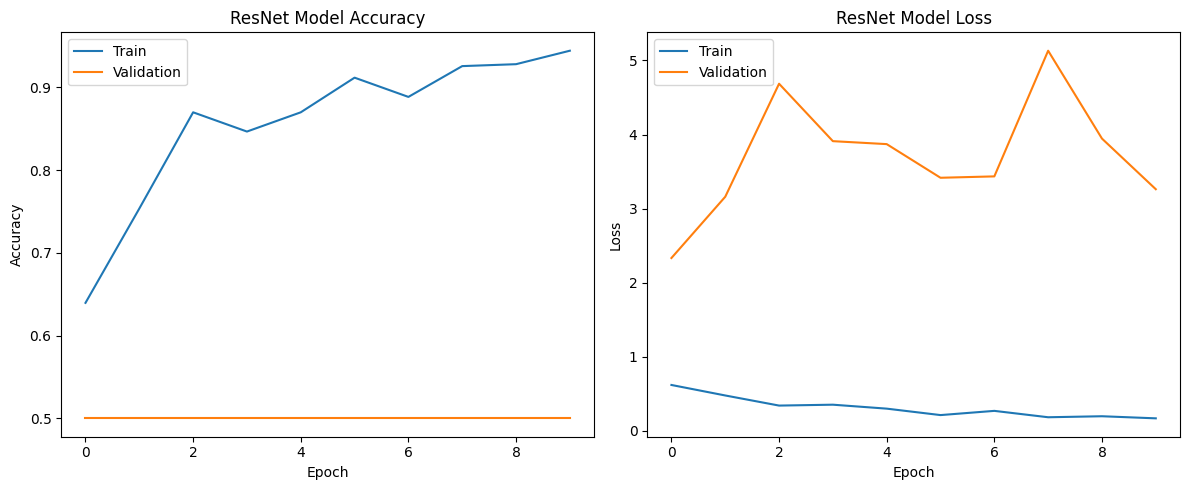

In [29]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_resnet.history['accuracy'])
plt.plot(history_resnet.history['val_accuracy'])
plt.title('ResNet Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_resnet.history['loss'])
plt.plot(history_resnet.history['val_loss'])
plt.title('ResNet Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [30]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

preds = model_resnet.predict(val_data)
preds = (preds > 0.5).astype(int)

true_labels = val_data.classes

cm = confusion_matrix(true_labels, preds)
print(cm)

print(classification_report(true_labels, preds))

7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 781ms/step
[[53  0]
 [53  0]]
              precision    recall  f1-score   support

           0       0.50      1.00      0.67        53
           1       0.00      0.00      0.00        53

    accuracy                           0.50       106
   macro avg       0.25      0.50      0.33       106
weighted avg       0.25      0.50      0.33       106



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
luna16_dataset_path = "/content/drive/MyDrive/dataset_file/seg-lungs-LUNA16/seg-lungs-LUNA16"
print(f"LUNA16 dataset path: {luna16_dataset_path}")

LUNA16 dataset path: /content/drive/MyDrive/dataset_file/seg-lungs-LUNA16/seg-lungs-LUNA16


In [32]:
import os

print(os.listdir(luna16_dataset_path))

['1.3.6.1.4.1.14519.5.2.1.6279.6001.233001470265230594739708503198.zraw', '1.3.6.1.4.1.14519.5.2.1.6279.6001.240969450540588211676803094518.zraw', '1.3.6.1.4.1.14519.5.2.1.6279.6001.239358021703233250639913775427.mhd', '1.3.6.1.4.1.14519.5.2.1.6279.6001.232071262560365924176679652948.mhd', '1.3.6.1.4.1.14519.5.2.1.6279.6001.241717018262666382493757419144.mhd', '1.3.6.1.4.1.14519.5.2.1.6279.6001.231645134739451754302647733304.mhd', '1.3.6.1.4.1.14519.5.2.1.6279.6001.232011770495640253949434620907.mhd', '1.3.6.1.4.1.14519.5.2.1.6279.6001.242624386080831911167122628616.zraw', '1.3.6.1.4.1.14519.5.2.1.6279.6001.241083615484551649610616348856.mhd', '1.3.6.1.4.1.14519.5.2.1.6279.6001.237428977311365557972720635401.zraw', '1.3.6.1.4.1.14519.5.2.1.6279.6001.242761658169703141430370511586.zraw', '1.3.6.1.4.1.14519.5.2.1.6279.6001.241083615484551649610616348856.zraw', '1.3.6.1.4.1.14519.5.2.1.6279.6001.237915456403882324748189195892.mhd', '1.3.6.1.4.1.14519.5.2.1.6279.6001.2318347763658747884407

In [33]:
base_path = "/content/drive/MyDrive/dataset_file/Lung_dataset_2"

In [34]:
import os

print(os.listdir(base_path))

['lung_ct_version_n_512.v2i.voc', 'lung_ct_version_n_512.v2i.yolov8', 'lung_ct_version_n_512.v2i.coco']


In [35]:
dataset_path = os.path.join(base_path, "lung_ct_version_n_512.v2i.coco")

print(os.listdir(dataset_path))

['README.dataset.txt', 'README.roboflow.txt', 'valid', 'test', 'train']


Loading sample scan: 1.3.6.1.4.1.14519.5.2.1.6279.6001.239358021703233250639913775427.mhd
Sample scan shape: (133, 512, 512)


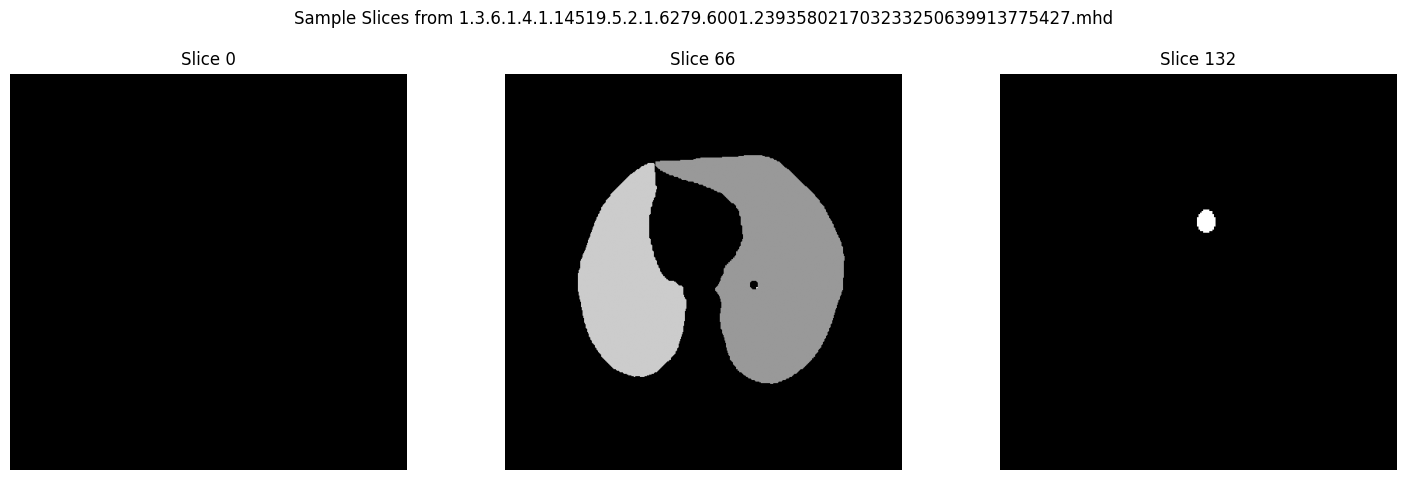

In [36]:
import SimpleITK as sitk
import matplotlib.pyplot as plt
import os
import numpy as np

# 🔹 Load .mhd scan
def load_mhd(path):
    image = sitk.ReadImage(path)
    scan = sitk.GetArrayFromImage(image)
    return scan

# Ensure selected_files is defined, or pick one directly if not already in context
# Assuming selected_files is available from previous execution (cell X--dqRv3Z8hX)

if 'selected_files' not in locals() or not selected_files:
    # If selected_files isn't available, re-initialize it for demonstration
    mhd_files = [f for f in os.listdir(luna16_dataset_path) if f.endswith(".mhd")]
    selected_files = mhd_files[:1] # Just pick the first one for a quick demo

if not selected_files:
    print("No .mhd files found in the LUNA16 dataset path.")
else:
    sample_mhd_file = selected_files[0]
    sample_path = os.path.join(luna16_dataset_path, sample_mhd_file)

    print(f"Loading sample scan: {sample_mhd_file}")

    # Load the scan using the previously defined function
    sample_scan = load_mhd(sample_path)

    print(f"Sample scan shape: {sample_scan.shape}")

    # Visualize a few slices from the middle of the scan
    num_slices_to_display = 3
    total_slices = sample_scan.shape[0]

    if total_slices == 0:
        print("The loaded scan has no slices to display.")
    else:
        # Calculate indices for slices to display (e.g., beginning, middle, end)
        slice_indices = [
            0,
            total_slices // 2,
            total_slices - 1
        ]
        # Filter out duplicates if total_slices < 3
        slice_indices = sorted(list(set([idx for idx in slice_indices if idx < total_slices])))

        plt.figure(figsize=(15, 5))
        for i, slice_idx in enumerate(slice_indices):
            plt.subplot(1, len(slice_indices), i + 1)
            plt.imshow(sample_scan[slice_idx], cmap='gray')
            plt.title(f'Slice {slice_idx}')
            plt.axis('off')
        plt.suptitle(f'Sample Slices from {sample_mhd_file}')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    # Free memory
    del sample_scan


### Preparing a subset of LUNA16 data for training

In [37]:
import os
import random
import shutil

# Define source directories from the balanced LUNA16 dataset
source_benign_dir = "/content/balanced_dataset/benign"
source_malignant_dir = "/content/balanced_dataset/malignant"

# Define the new target directory for the subset
luna16_train_subset_dir = "/content/luna16_train_subset"
output_benign_dir = os.path.join(luna16_train_subset_dir, "benign")
output_malignant_dir = os.path.join(luna16_train_subset_dir, "malignant")

# Clean up existing output directory if it exists
shutil.rmtree(luna16_train_subset_dir, ignore_errors=True)

# Create target directories
os.makedirs(output_benign_dir, exist_ok=True)
os.makedirs(output_malignant_dir, exist_ok=True)

num_images_per_class = 50

print(f"Selecting {num_images_per_class} images per class from LUNA16 balanced dataset...")

# Get all file names from source directories
all_benign_files = os.listdir(source_benign_dir)
all_malignant_files = os.listdir(source_malignant_dir)

# Randomly select 50 benign images
selected_benign_files = random.sample(all_benign_files, min(num_images_per_class, len(all_benign_files)))
for f in selected_benign_files:
    shutil.copy(os.path.join(source_benign_dir, f),
                os.path.join(output_benign_dir, f))

# Randomly select 50 malignant images
selected_malignant_files = random.sample(all_malignant_files, min(num_images_per_class, len(all_malignant_files)))
for f in selected_malignant_files:
    shutil.copy(os.path.join(source_malignant_dir, f),
                os.path.join(output_malignant_dir, f))

print("LUNA16 training subset created!")
print(f"Benign images in subset: {len(os.listdir(output_benign_dir))}")
print(f"Malignant images in subset: {len(os.listdir(output_malignant_dir))}")

Selecting 50 images per class from LUNA16 balanced dataset...
LUNA16 training subset created!
Benign images in subset: 50
Malignant images in subset: 50


Loading benign images...
Loading malignant images...
Total images loaded: 100
Shape of feature matrix X: (100, 4096)
Shape of labels y: (100,)
Training set size: 80 images
Test set size: 20 images
Training Random Forest Classifier...
Training complete.
Evaluating the model...
Accuracy: 0.7000

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.60      0.67        10
           1       0.67      0.80      0.73        10

    accuracy                           0.70        20
   macro avg       0.71      0.70      0.70        20
weighted avg       0.71      0.70      0.70        20


Confusion Matrix:
[[6 4]
 [2 8]]


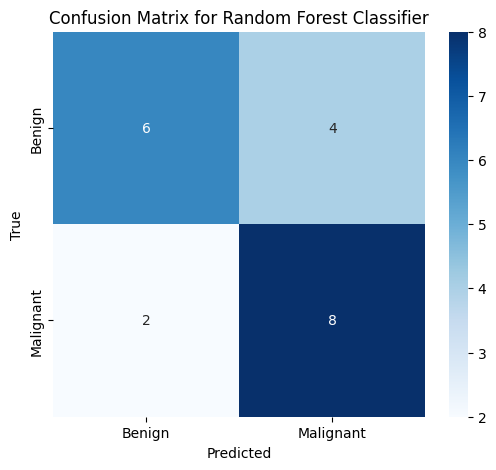

In [38]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define paths to the LUNA16 training subset
luna16_train_subset_dir = "/content/luna16_train_subset"
output_benign_dir = os.path.join(luna16_train_subset_dir, "benign")
output_malignant_dir = os.path.join(luna16_train_subset_dir, "malignant")

# --- 1. Load Images and Preprocess ---

images = []
labels = [] # 0 for benign, 1 for malignant

# Load benign images
print("Loading benign images...")
for filename in os.listdir(output_benign_dir):
    if filename.endswith('.png'): # Assuming images are saved as PNG
        img_path = os.path.join(output_benign_dir, filename)
        img = Image.open(img_path).convert('L') # Convert to grayscale
        img = img.resize((64, 64)) # Resize for consistency and reduced computational load
        images.append(np.array(img).flatten()) # Flatten image to 1D array
        labels.append(0) # Benign label

# Load malignant images
print("Loading malignant images...")
for filename in os.listdir(output_malignant_dir):
    if filename.endswith('.png'):
        img_path = os.path.join(output_malignant_dir, filename)
        img = Image.open(img_path).convert('L') # Convert to grayscale
        img = img.resize((64, 64)) # Resize
        images.append(np.array(img).flatten()) # Flatten image to 1D array
        labels.append(1) # Malignant label

# Convert lists to numpy arrays
X = np.array(images)
y = np.array(labels)

print(f"Total images loaded: {len(X)}")
print(f"Shape of feature matrix X: {X.shape}")
print(f"Shape of labels y: {y.shape}")

# --- 2. Split Data ---

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)} images")
print(f"Test set size: {len(X_test)} images")

# --- 3. Train Random Forest Classifier ---

print("Training Random Forest Classifier...")
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_classifier.fit(X_train, y_train)
print("Training complete.")

# --- 4. Evaluate the Model ---

print("Evaluating the model...")
y_pred = rf_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Random Forest Classifier')
plt.show()


Training Support Vector Machine Classifier...
Training complete.
Evaluating the SVM model...
SVM Accuracy: 0.6000

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.50      0.56        10
           1       0.58      0.70      0.64        10

    accuracy                           0.60        20
   macro avg       0.60      0.60      0.60        20
weighted avg       0.60      0.60      0.60        20


SVM Confusion Matrix:
[[5 5]
 [3 7]]


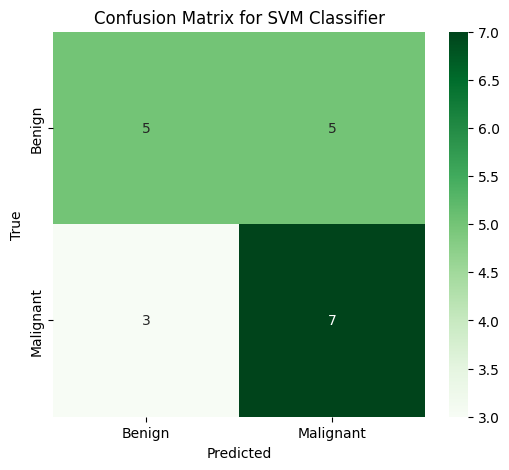

In [39]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming X_train, X_test, y_train, y_test are already defined from the previous Random Forest Classifier cell

# --- 1. Initialize and Train SVM Classifier ---

print("Training Support Vector Machine Classifier...")
# Use a linear kernel for simplicity and often good performance on high-dimensional data
# class_weight='balanced' helps handle potential class imbalances
svm_classifier = SVC(kernel='linear', random_state=42, class_weight='balanced')
svm_classifier.fit(X_train, y_train)
print("Training complete.")

# --- 2. Evaluate the Model ---

print("Evaluating the SVM model...")
y_pred_svm = svm_classifier.predict(X_test)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {accuracy_svm:.4f}")

print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

print("\nSVM Confusion Matrix:")
cm_svm = confusion_matrix(y_test, y_pred_svm)
print(cm_svm)

# Visualize Confusion Matrix for SVM
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for SVM Classifier')
plt.show()


### Merging LUNA16 and COCO Datasets

Created merged dataset directories: /content/merged_classification_dataset/negative_malignant and /content/merged_classification_dataset/positive_malignant

Copying benign images from LUNA16 subset (/content/luna16_train_subset/benign) to '/content/merged_classification_dataset/negative_malignant'...
Copied 50 benign images.

Copying malignant images from LUNA16 subset (/content/luna16_train_subset/malignant) to '/content/merged_classification_dataset/positive_malignant'...

Copying malignant images from COCO dataset (/content/drive/MyDrive/dataset_file/Lung_dataset_2/lung_ct_version_n_512.v2i.coco) to '/content/merged_classification_dataset/positive_malignant'...
  Processing COCO 'train' split from: /content/drive/MyDrive/dataset_file/Lung_dataset_2/lung_ct_version_n_512.v2i.coco/train
  Processing COCO 'valid' split from: /content/drive/MyDrive/dataset_file/Lung_dataset_2/lung_ct_version_n_512.v2i.coco/valid
  Processing COCO 'test' split from: /content/drive/MyDrive/dataset_file/Lu

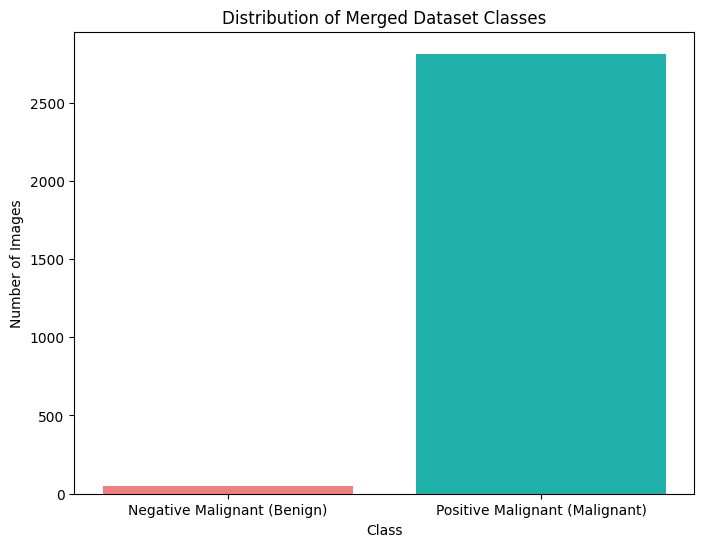

In [40]:
import os
import shutil
import matplotlib.pyplot as plt

# Define new root directory for the merged dataset
merged_dataset_root = "/content/merged_classification_dataset"
merged_negative_dir = os.path.join(merged_dataset_root, "negative_malignant")
merged_positive_dir = os.path.join(merged_dataset_root, "positive_malignant")

# Clean up existing merged directory if it exists
shutil.rmtree(merged_dataset_root, ignore_errors=True)

# Create new directories
os.makedirs(merged_negative_dir, exist_ok=True)
os.makedirs(merged_positive_dir, exist_ok=True)

print(f"Created merged dataset directories: {merged_negative_dir} and {merged_positive_dir}")

# --- Copy Benign Images to 'negative_malignant' ---
luna16_benign_source_dir = "/content/luna16_train_subset/benign"
print(f"\nCopying benign images from LUNA16 subset ({luna16_benign_source_dir}) to '{merged_negative_dir}'...")
benign_images_copied = 0
for filename in os.listdir(luna16_benign_source_dir):
    if filename.endswith(('.png', '.jpg', '.jpeg')):
        shutil.copy(os.path.join(luna16_benign_source_dir, filename),
                    os.path.join(merged_negative_dir, filename))
        benign_images_copied += 1
print(f"Copied {benign_images_copied} benign images.")

# --- Copy Malignant Images to 'positive_malignant' ---
malignant_images_copied = 0

# From LUNA16 subset
luna16_malignant_source_dir = "/content/luna16_train_subset/malignant"
print(f"\nCopying malignant images from LUNA16 subset ({luna16_malignant_source_dir}) to '{merged_positive_dir}'...")
for filename in os.listdir(luna16_malignant_source_dir):
    if filename.endswith(('.png', '.jpg', '.jpeg')):
        # Prepend 'luna16_' to avoid potential filename clashes
        new_filename = f"luna16_{filename}"
        shutil.copy(os.path.join(luna16_malignant_source_dir, filename),
                    os.path.join(merged_positive_dir, new_filename))
        malignant_images_copied += 1

# From COCO dataset (train, valid, test splits)
coco_base_dir = "/content/drive/MyDrive/dataset_file/Lung_dataset_2/lung_ct_version_n_512.v2i.coco"
coco_splits = ["train", "valid", "test"]

print(f"\nCopying malignant images from COCO dataset ({coco_base_dir}) to '{merged_positive_dir}'...")
for split in coco_splits:
    coco_split_dir = os.path.join(coco_base_dir, split)
    if os.path.exists(coco_split_dir):
        print(f"  Processing COCO '{split}' split from: {coco_split_dir}")
        for filename in os.listdir(coco_split_dir):
            if filename.endswith(('.jpg', '.png', '.jpeg')):
                # Prepend 'coco_split_' to ensure unique filenames across sources and splits
                new_filename = f"coco_{split}_{filename}"
                shutil.copy(os.path.join(coco_split_dir, filename),
                            os.path.join(merged_positive_dir, new_filename))
                malignant_images_copied += 1
    else:
        # This else branch should ideally not be hit if the path is correct
        # as the diagnostic already confirmed existence of example_split_dir
        print(f"  COCO split directory not found: {coco_split_dir}")

print(f"\nCopied {malignant_images_copied} malignant images in total.")

# --- Verify counts and visualize distribution ---
final_benign_count = len(os.listdir(merged_negative_dir))
final_malignant_count = len(os.listdir(merged_positive_dir))

print(f"\nMerged dataset created at '{merged_dataset_root}':")
print(f"  Negative Malignant (Benign) images: {final_benign_count}")
print(f"  Positive Malignant (Malignant) images: {final_malignant_count}")

labels = ['Negative Malignant (Benign)', 'Positive Malignant (Malignant)']
counts = [final_benign_count, final_malignant_count]

plt.figure(figsize=(8, 6))
plt.bar(labels, counts, color=['lightcoral', 'lightseagreen'])
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Distribution of Merged Dataset Classes')
plt.show()

Rebalancing the merged dataset by adding more benign images...
Current benign images in merged dataset: 50
Current malignant images in merged dataset: 2812
Need to add 2762 more benign images.
Copied 2762 additional benign images to '/content/merged_classification_dataset/negative_malignant'.

Merged dataset rebalanced at '/content/merged_classification_dataset':
  Negative Malignant (Benign) images: 2812
  Positive Malignant (Malignant) images: 2812


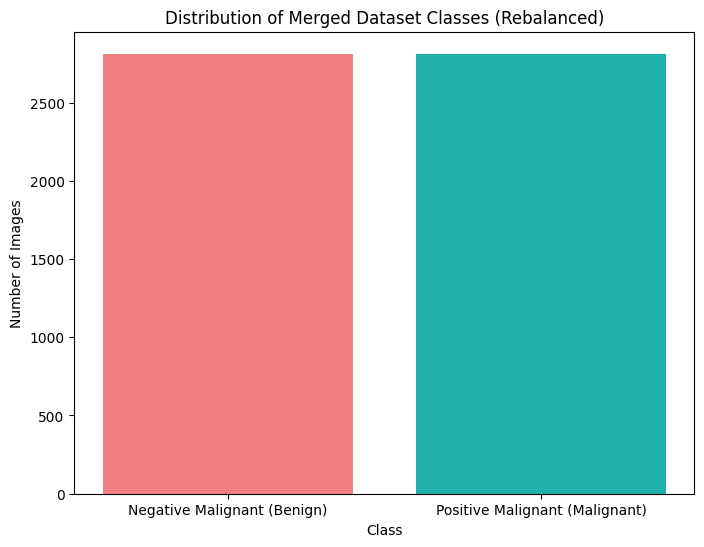

In [41]:
import os
import shutil
import random
import matplotlib.pyplot as plt

# Define directories for the merged dataset
merged_dataset_root = "/content/merged_classification_dataset"
merged_negative_dir = os.path.join(merged_dataset_root, "negative_malignant")
merged_positive_dir = os.path.join(merged_dataset_root, "positive_malignant")

# Source for additional benign images (the original LUNA16 processed dataset)
original_benign_dir = "/content/dataset/benign"

print("Rebalancing the merged dataset by adding more benign images...")

# --- Determine target count ---
# Get the current count of malignant images in the merged dataset
current_malignant_count = len(os.listdir(merged_positive_dir))
current_benign_count = len(os.listdir(merged_negative_dir))

print(f"Current benign images in merged dataset: {current_benign_count}")
print(f"Current malignant images in merged dataset: {current_malignant_count}")

# We want to match the malignant count, so target is current_malignant_count
target_benign_count = current_malignant_count

# Calculate how many more benign images are needed
needed_additional_benign_images = target_benign_count - current_benign_count

if needed_additional_benign_images > 0:
    print(f"Need to add {needed_additional_benign_images} more benign images.")

    # Get all available benign files from the original LUNA16 processed dataset
    all_original_benign_files = os.listdir(original_benign_dir)

    if len(all_original_benign_files) < needed_additional_benign_images:
        print(f"Warning: Not enough benign images in {original_benign_dir} ({len(all_original_benign_files)}) to reach target {target_benign_count}.")
        # If not enough, copy all available
        files_to_copy = all_original_benign_files
    else:
        # Randomly select the required number of additional benign images
        files_to_copy = random.sample(all_original_benign_files, needed_additional_benign_images)

    # Copy the selected benign images to the merged_negative_dir
    copied_count = 0
    for filename in files_to_copy:
        src_path = os.path.join(original_benign_dir, filename)
        # Prepend 'luna16_original_benign_' to avoid potential filename clashes
        dest_filename = f"luna16_original_benign_{filename}"
        dest_path = os.path.join(merged_negative_dir, dest_filename)
        shutil.copy(src_path, dest_path)
        copied_count += 1
    print(f"Copied {copied_count} additional benign images to '{merged_negative_dir}'.")
else:
    print("Benign count is already sufficient or greater than malignant count. No additional benign images copied.")

# --- Verify new counts and visualize distribution ---
final_benign_count_rebalanced = len(os.listdir(merged_negative_dir))
final_malignant_count_rebalanced = len(os.listdir(merged_positive_dir))

print(f"\nMerged dataset rebalanced at '{merged_dataset_root}':")
print(f"  Negative Malignant (Benign) images: {final_benign_count_rebalanced}")
print(f"  Positive Malignant (Malignant) images: {final_malignant_count_rebalanced}")

labels = ['Negative Malignant (Benign)', 'Positive Malignant (Malignant)']
counts = [final_benign_count_rebalanced, final_malignant_count_rebalanced]

plt.figure(figsize=(8, 6))
plt.bar(labels, counts, color=['lightcoral', 'lightseagreen'])
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Distribution of Merged Dataset Classes (Rebalanced)')
plt.show()


### Re-initializing ImageDataGenerator with the Balanced Merged Dataset

Now that the dataset has been successfully merged and rebalanced to have 2812 images per class, it's crucial to re-initialize the `ImageDataGenerator`s. This ensures that the training and validation data generators correctly load all available images from the `/content/merged_classification_dataset` directory and reflect the balanced class distribution for model training and evaluation.

In [42]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the root directory for the merged dataset
data_dir = "/content/merged_classification_dataset"

# Image dimensions and batch size (consistent with previous models)
img_size = (224, 224)
batch_size = 16

# Set a random seed for reproducibility in data splitting and augmentation
SEED = 42

# Create an ImageDataGenerator for data augmentation and splitting
datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values to [0, 1]
    validation_split=0.2,     # 20% of data for validation (testing)
    # Optional: Add augmentation for robustness during training
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

# Training data generator
train_data_merged = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',      # For binary classification (negative_malignant vs positive_malignant)
    subset='training',
    seed=SEED                 # Specify training subset
)

# Validation (test) data generator
val_data_merged = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',      # For binary classification
    subset='validation',
    seed=SEED                 # Specify validation subset
)

print("\nData generators for merged dataset created successfully.")
print(f"Training data classes: {train_data_merged.class_indices}")
print(f"Validation data classes: {val_data_merged.class_indices}")
print(f"Total images in training set: {train_data_merged.samples}")
print(f"Total images in validation set: {val_data_merged.samples}")

# Print a sample of file paths to visually inspect for overlap
print("\nSample of training file paths (first 5):\n", train_data_merged.filepaths[:5])
print("\nSample of validation file paths (first 5):\n", val_data_merged.filepaths[:5])


Found 4500 images belonging to 2 classes.
Found 1124 images belonging to 2 classes.

Data generators for merged dataset created successfully.
Training data classes: {'negative_malignant': 0, 'positive_malignant': 1}
Validation data classes: {'negative_malignant': 0, 'positive_malignant': 1}
Total images in training set: 4500
Total images in validation set: 1124

Sample of training file paths (first 5):
 ['/content/merged_classification_dataset/negative_malignant/luna16_original_benign_1.3.6.1.4.1.14519.5.2.1.6279.6001.233433352108264931671753343044_slice_283.png', '/content/merged_classification_dataset/negative_malignant/luna16_original_benign_1.3.6.1.4.1.14519.5.2.1.6279.6001.233433352108264931671753343044_slice_297.png', '/content/merged_classification_dataset/negative_malignant/luna16_original_benign_1.3.6.1.4.1.14519.5.2.1.6279.6001.233433352108264931671753343044_slice_298.png', '/content/merged_classification_dataset/negative_malignant/luna16_original_benign_1.3.6.1.4.1.14519.5.2

Preparing data for Random Forest Classifier from newly initialized generators...
Training data shape (flattened): (4500, 150528)
Training labels shape: (4500,)
Test data shape (flattened): (1124, 150528)
Test labels shape: (1124,)

Training Random Forest Classifier on merged data...
Random Forest Training complete.

Evaluating the Random Forest model...
Random Forest Accuracy: 0.9982

Random Forest Classification Report:
                    precision    recall  f1-score   support

negative_malignant       1.00      1.00      1.00       562
positive_malignant       1.00      1.00      1.00       562

          accuracy                           1.00      1124
         macro avg       1.00      1.00      1.00      1124
      weighted avg       1.00      1.00      1.00      1124


Random Forest Confusion Matrix:
[[560   2]
 [  0 562]]


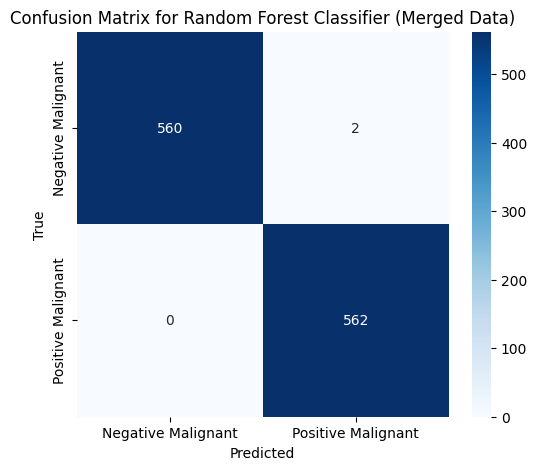

In [43]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Preparing data for Random Forest Classifier from newly initialized generators...")

# Reset generators to ensure they start from the beginning
train_data_merged.reset()
val_data_merged.reset()

# Function to extract all images and labels from a generator
def extract_from_generator(generator):
    all_images = []
    all_labels = []
    # Iterate through all batches in the generator
    for _ in range(len(generator)):
        images, labels = next(generator) # Corrected: use next() built-in function
        all_images.append(images)
        all_labels.append(labels)
    # Concatenate all batches
    return np.vstack(all_images), np.hstack(all_labels)

# Extract training data
X_train_merged_raw, y_train_merged = extract_from_generator(train_data_merged)
# Extract validation (test) data
X_test_merged_raw, y_test_merged = extract_from_generator(val_data_merged)

# Ensure labels are integers (0 or 1)
y_train_merged = y_train_merged.astype(int)
y_test_merged = y_test_merged.astype(int)

# Flatten images: (num_samples, height, width, channels) to (num_samples, height * width * channels)
X_train_flat = X_train_merged_raw.reshape(X_train_merged_raw.shape[0], -1)
X_test_flat = X_test_merged_raw.reshape(X_test_merged_raw.shape[0], -1)

print(f"Training data shape (flattened): {X_train_flat.shape}")
print(f"Training labels shape: {y_train_merged.shape}")
print(f"Test data shape (flattened): {X_test_flat.shape}")
print(f"Test labels shape: {y_test_merged.shape}")

# --- 2. Train Random Forest Classifier ---

print("\nTraining Random Forest Classifier on merged data...")
rf_classifier_merged = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_classifier_merged.fit(X_train_flat, y_train_merged)
print("Random Forest Training complete.")

# --- 3. Evaluate the Model ---

print("\nEvaluating the Random Forest model...")
y_pred_rf_merged = rf_classifier_merged.predict(X_test_flat)

accuracy_rf_merged = accuracy_score(y_test_merged, y_pred_rf_merged)
print(f"Random Forest Accuracy: {accuracy_rf_merged:.4f}")

print("\nRandom Forest Classification Report:")
print(classification_report(y_test_merged, y_pred_rf_merged, target_names=['negative_malignant', 'positive_malignant']))

print("\nRandom Forest Confusion Matrix:")
cm_rf_merged = confusion_matrix(y_test_merged, y_pred_rf_merged)
print(cm_rf_merged)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf_merged, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative Malignant', 'Positive Malignant'],
            yticklabels=['Negative Malignant', 'Positive Malignant'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Random Forest Classifier (Merged Data)')
plt.show()

Training Naive Bayes Classifier on merged data...
Naive Bayes Training complete.

Evaluating the Naive Bayes model...
Naive Bayes Accuracy: 0.9626

Naive Bayes Classification Report:
                    precision    recall  f1-score   support

negative_malignant       0.93      1.00      0.96       562
positive_malignant       1.00      0.93      0.96       562

          accuracy                           0.96      1124
         macro avg       0.96      0.96      0.96      1124
      weighted avg       0.96      0.96      0.96      1124


Naive Bayes Confusion Matrix:
[[561   1]
 [ 41 521]]


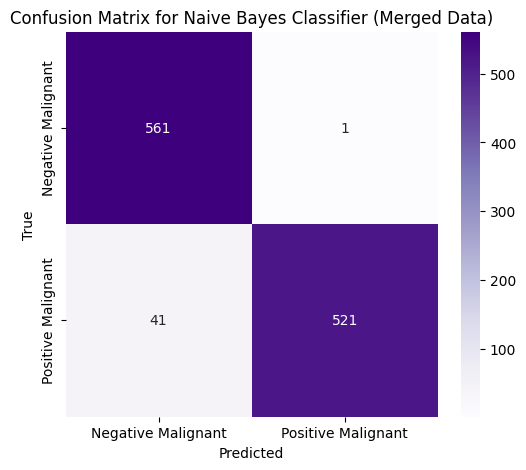

In [44]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Training Naive Bayes Classifier on merged data...")

# Initialize and Train Naive Bayes Classifier
nb_classifier_merged = GaussianNB()
nb_classifier_merged.fit(X_train_flat, y_train_merged)

print("Naive Bayes Training complete.")

# Evaluate the Model
print("\nEvaluating the Naive Bayes model...")
y_pred_nb_merged = nb_classifier_merged.predict(X_test_flat)

accuracy_nb_merged = accuracy_score(y_test_merged, y_pred_nb_merged)
print(f"Naive Bayes Accuracy: {accuracy_nb_merged:.4f}")

print("\nNaive Bayes Classification Report:")
print(classification_report(y_test_merged, y_pred_nb_merged, target_names=['negative_malignant', 'positive_malignant']))

print("\nNaive Bayes Confusion Matrix:")
cm_nb_merged = confusion_matrix(y_test_merged, y_pred_nb_merged)
print(cm_nb_merged)

# Visualize Confusion Matrix for Naive Bayes
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb_merged, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Negative Malignant', 'Positive Malignant'],
            yticklabels=['Negative Malignant', 'Positive Malignant'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Naive Bayes Classifier (Merged Data)')
plt.show()

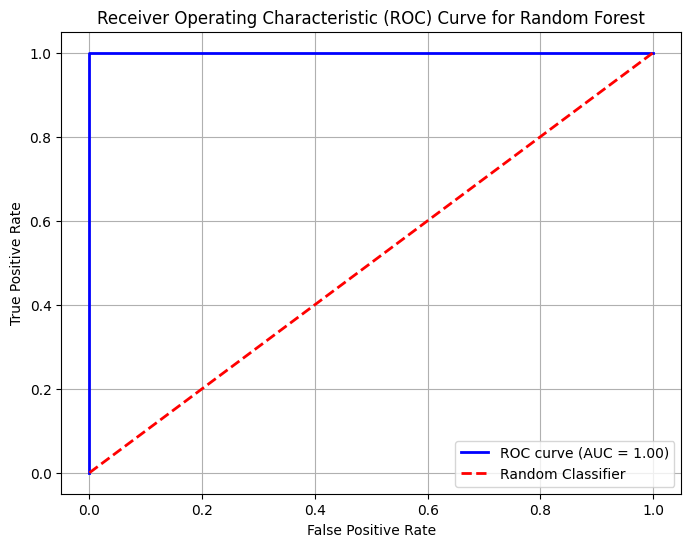

Random Forest Classifier AUC: 1.0000


In [45]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (malignant) for Random Forest
# rf_classifier_merged, X_test_flat, and y_test_merged are available from cell YV5hUN04ki9c
y_pred_proba_rf = rf_classifier_merged.predict_proba(X_test_flat)[:, 1]

# Calculate ROC curve
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test_merged, y_pred_proba_rf)

# Calculate AUC
auc_rf = auc(fpr_rf, tpr_rf)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'ROC curve (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"Random Forest Classifier AUC: {auc_rf:.4f}")

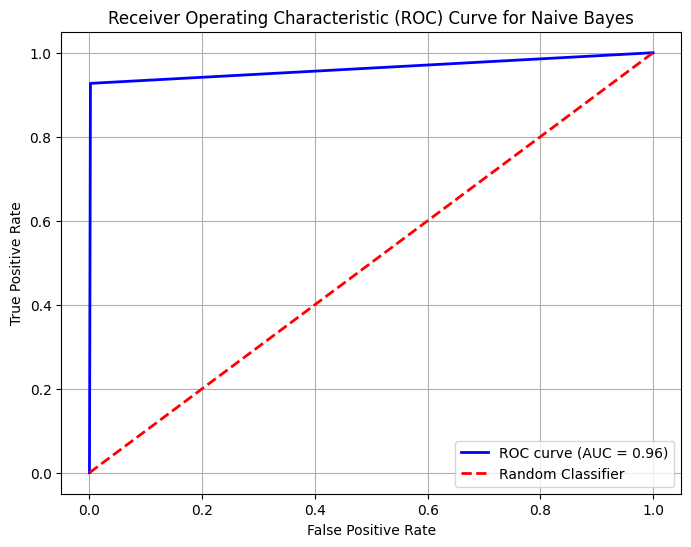

Naive Bayes Classifier AUC: 0.9626


In [46]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class for Naive Bayes
# nb_classifier_merged, X_test_flat, and y_test_merged are available from cell MCFgXx7QFuVv and YV5hUN04ki9c
y_pred_proba_nb = nb_classifier_merged.predict_proba(X_test_flat)[:, 1]

# Calculate ROC curve
fpr_nb, tpr_nb, thresholds_nb = roc_curve(y_test_merged, y_pred_proba_nb)

# Calculate AUC
auc_nb = auc(fpr_nb, tpr_nb)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_nb, tpr_nb, color='blue', lw=2, label=f'ROC curve (AUC = {auc_nb:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Naive Bayes')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"Naive Bayes Classifier AUC: {auc_nb:.4f}")

### Training a Convolutional Neural Network (CNN) on the Merged Dataset

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

print("Defining and compiling an improved CNN model...")

# Define the improved CNN model architecture
cnn_model_merged = Sequential([
    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(img_size[0], img_size[1], 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), padding='same', activation='relu'), # Added a new convolutional block
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'), # Increased dense layer units
    BatchNormalization(), # Added BatchNormalization to dense layer
    Dropout(0.4), # Adjusted dropout rate

    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
cnn_model_merged.compile(
    optimizer=Adam(learning_rate=0.0001), # Reduced learning rate for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model_merged.summary()
print("Improved CNN model defined and compiled.")

Defining and compiling an improved CNN model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,236,929 (50.49 MB)

 Trainable params: 13,235,457 (50.49 MB)

 Non-trainable params: 1,472 (5.75 KB)

Improved CNN model defined and compiled.


In [49]:
print("\nTraining the CNN model on the merged dataset...")

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Adjust Class Weights for Balanced Dataset
# Since the merged dataset is now balanced (2812 benign, 2812 malignant),
# uniform class weights are appropriate.
class_weight_merged = {
    train_data_merged.class_indices['negative_malignant']: 1.0,
    train_data_merged.class_indices['positive_malignant']: 1.0
}
print(f"Using class weights: {class_weight_merged}")

# 2. Define Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5, # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2, # Factor by which the learning rate will be reduced. new_lr = lr * factor
    patience=3, # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=0.000001
)

callbacks_list = [early_stopping, reduce_lr]

# Train the CNN model using the merged dataset generators
history_cnn_merged = cnn_model_merged.fit(
    train_data_merged,
    validation_data=val_data_merged,
    epochs=20, # Increased epochs to allow for more learning with early stopping
    class_weight=class_weight_merged,
    callbacks=callbacks_list
)

print("\nCNN training complete.")


Training the CNN model on the merged dataset...
Using class weights: {0: 1.0, 1: 1.0}
Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 103s 328ms/step - accuracy: 0.9804 - loss: 0.0930 - val_accuracy: 0.5000 - val_loss: 0.7021 - learning_rate: 1.0000e-04
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 82s 293ms/step - accuracy: 0.9844 - loss: 0.0743 - val_accuracy: 1.0000 - val_loss: 0.0521 - learning_rate: 1.0000e-04
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 80s 283ms/step - accuracy: 0.9864 - loss: 0.0689 - val_accuracy: 0.9991 - val_loss: 0.0104 - learning_rate: 1.0000e-04
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 82s 290ms/step - accuracy: 0.9858 - loss: 0.0621 - val_accuracy: 0.9973 - val_loss: 0.0215 - learning_rate: 1.0000e-04
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 80s 284ms/step - accuracy: 0.9873 - loss: 0.0586 - val_accuracy: 1.0000 - val_loss: 0.0026 - learning_rate: 1.0000e-04
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 82s 291ms/step - accuracy: 0.9878 - loss: 0.0515 - val_accuracy: 0.9973 - val

71/71 ━━━━━━━━━━━━━━━━━━━━ 17s 230ms/step

CNN Confusion Matrix (Merged Dataset):
[[283 279]
 [279 283]]


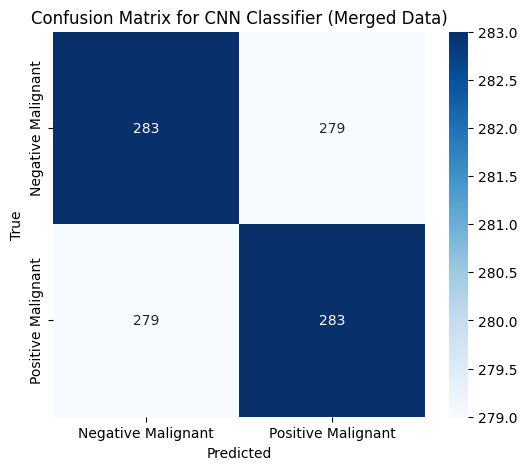


CNN Classification Report (Merged Dataset):
                    precision    recall  f1-score   support

negative_malignant       0.50      0.50      0.50       562
positive_malignant       0.50      0.50      0.50       562

          accuracy                           0.50      1124
         macro avg       0.50      0.50      0.50      1124
      weighted avg       0.50      0.50      0.50      1124



In [50]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the validation data
val_data_merged.reset() # Ensure the generator is at the beginning
predictions_cnn_merged = cnn_model_merged.predict(val_data_merged)

# Convert predictions to binary classes (0 or 1)
predicted_classes_cnn_merged = (predictions_cnn_merged > 0.5).astype(int)

# Get true labels from the validation data generator
true_classes_cnn_merged = val_data_merged.classes

# Calculate the confusion matrix
cm_cnn_merged = confusion_matrix(true_classes_cnn_merged, predicted_classes_cnn_merged)

print("\nCNN Confusion Matrix (Merged Dataset):")
print(cm_cnn_merged)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_cnn_merged, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative Malignant', 'Positive Malignant'],
            yticklabels=['Negative Malignant', 'Positive Malignant'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for CNN Classifier (Merged Data)')
plt.show()

# Print the classification report
print("\nCNN Classification Report (Merged Dataset):")
print(classification_report(true_classes_cnn_merged, predicted_classes_cnn_merged, target_names=['negative_malignant', 'positive_malignant']))

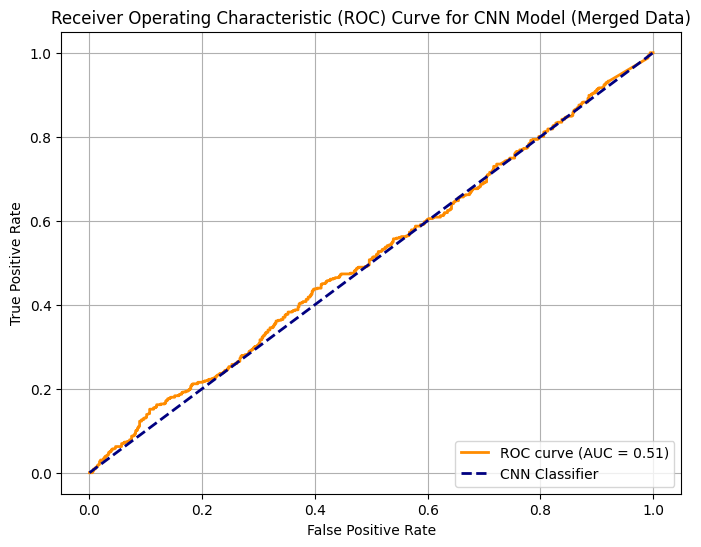

CNN Model (Merged Data) AUC: 0.5099


In [51]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Ensure val_data_merged is reset to get predictions in the correct order
val_data_merged.reset()

# Get predicted probabilities for the positive class from the CNN model
# predictions_cnn_merged and true_classes_cnn_merged are already available from cell Es0jbQdcqXHk
y_pred_proba_cnn_merged = predictions_cnn_merged.flatten()

# Calculate ROC curve
fpr_cnn_merged, tpr_cnn_merged, thresholds_cnn_merged = roc_curve(true_classes_cnn_merged, y_pred_proba_cnn_merged)

# Calculate AUC
auc_cnn_merged = auc(fpr_cnn_merged, tpr_cnn_merged)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_cnn_merged, tpr_cnn_merged, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_cnn_merged:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='CNN Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for CNN Model (Merged Data)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"CNN Model (Merged Data) AUC: {auc_cnn_merged:.4f}")

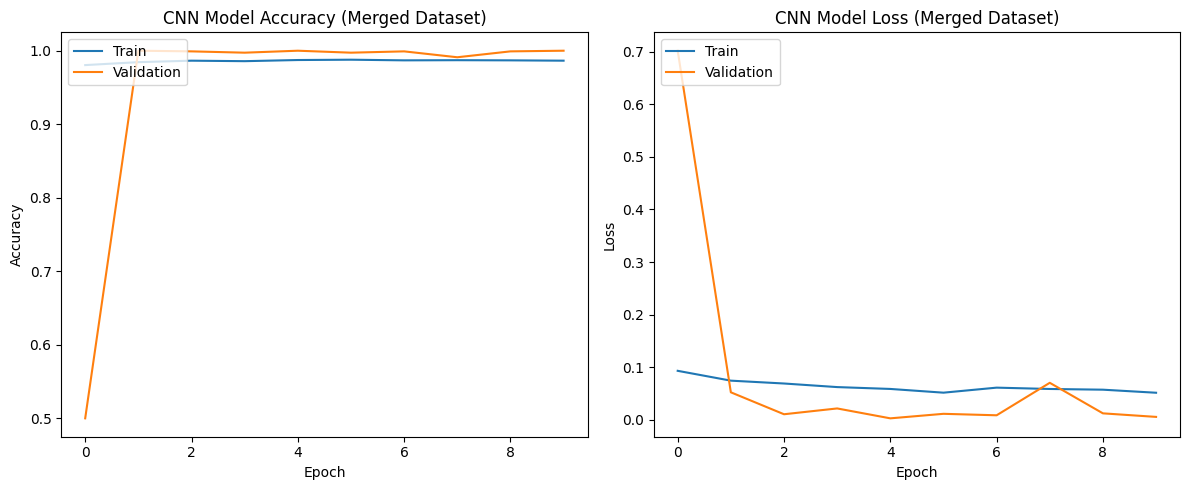

In [52]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_cnn_merged.history['accuracy'])
plt.plot(history_cnn_merged.history['val_accuracy'])
plt.title('CNN Model Accuracy (Merged Dataset)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_cnn_merged.history['loss'])
plt.plot(history_cnn_merged.history['val_loss'])
plt.title('CNN Model Loss (Merged Dataset)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [53]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Adjust Class Weights for Balanced Dataset
# Since the merged dataset is now balanced (2812 benign, 2812 malignant),
# uniform class weights are appropriate.
class_weight_merged = {
    train_data_merged.class_indices['negative_malignant']: 1.0,
    train_data_merged.class_indices['positive_malignant']: 1.0
}
print(f"Using class weights: {class_weight_merged}")

# 2. Define Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5, # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2, # Factor by which the learning rate will be reduced. new_lr = lr * factor
    patience=3, # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=0.000001
)

callbacks_list = [early_stopping, reduce_lr]

Using class weights: {0: 1.0, 1: 1.0}


In [54]:

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Redefine and compile model_resnet to ensure it exists
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Unfreeze last 30 layers
for layer in base_model.layers[-30:]:
    layer.trainable = True

# Custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model_resnet = Model(inputs=base_model.input, outputs=output)

model_resnet.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nStarting ResNet training on merged dataset...")
history_resnet_merged = model_resnet.fit(
    train_data_merged,
    validation_data=val_data_merged,
    epochs=8, # Increased epochs, but early stopping will prevent overfitting
    class_weight=class_weight_merged,
    callbacks=callbacks_list
)
print("ResNet training complete.")


Starting ResNet training on merged dataset...
Epoch 1/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 188s 462ms/step - accuracy: 0.9864 - loss: 0.0622 - val_accuracy: 0.5000 - val_loss: 2.8038 - learning_rate: 1.0000e-04
Epoch 2/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 96s 341ms/step - accuracy: 0.9891 - loss: 0.0492 - val_accuracy: 0.5098 - val_loss: 1.2131 - learning_rate: 1.0000e-04
Epoch 3/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 94s 334ms/step - accuracy: 0.9889 - loss: 0.0478 - val_accuracy: 1.0000 - val_loss: 0.0214 - learning_rate: 1.0000e-04
Epoch 4/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 97s 343ms/step - accuracy: 0.9893 - loss: 0.0465 - val_accuracy: 1.0000 - val_loss: 0.0206 - learning_rate: 1.0000e-04
Epoch 5/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 97s 343ms/step - accuracy: 0.9878 - loss: 0.0441 - val_accuracy: 1.0000 - val_loss: 0.0376 - learning_rate: 1.0000e-04
Epoch 6/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 97s 341ms/step - accuracy: 0.9887 - loss: 0.0419 - val_accuracy: 1.0000 - val_loss: 0.0033 - learning_rate: 1.0000e-04
Epoc

In [55]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# 4. Evaluate the Model
print("\n--- Evaluating ResNet Model Performance ---")
loss_resnet_merged, acc_resnet_merged = model_resnet.evaluate(val_data_merged)
print(f"Validation Accuracy (ResNet Merged): {acc_resnet_merged:.4f}")
print(f"Validation Loss (ResNet Merged): {loss_resnet_merged:.4f}")

val_data_merged.reset()
predictions_resnet_merged = model_resnet.predict(val_data_merged)
predicted_classes_resnet_merged = (predictions_resnet_merged > 0.5).astype(int)

true_classes_resnet_merged = val_data_merged.classes


--- Evaluating ResNet Model Performance ---
71/71 ━━━━━━━━━━━━━━━━━━━━ 17s 241ms/step - accuracy: 1.0000 - loss: 0.0036
Validation Accuracy (ResNet Merged): 1.0000
Validation Loss (ResNet Merged): 0.0036
71/71 ━━━━━━━━━━━━━━━━━━━━ 24s 283ms/step


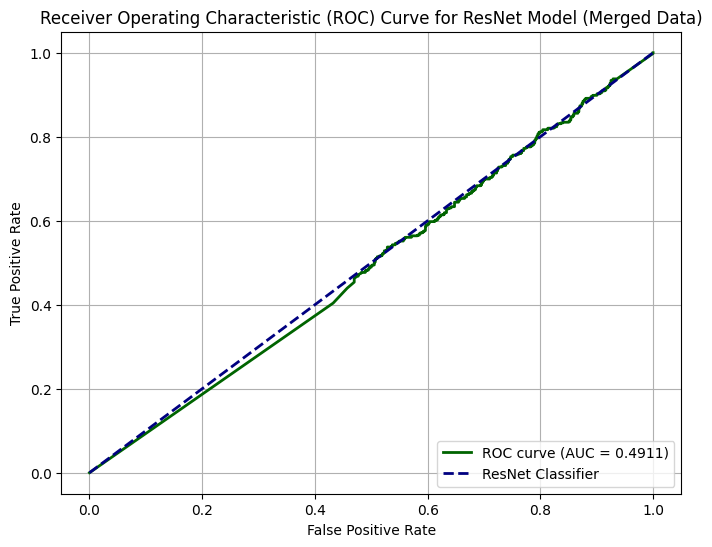

ResNet Model (Merged Data) AUC: 0.4911


In [56]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Ensure val_data_merged is reset to get predictions in the correct order
val_data_merged.reset()

# Get predicted probabilities for the positive class from the ResNet model
# predictions_resnet_merged and true_classes_resnet_merged are already available from cell Ba-X0S_d1jJ
y_pred_proba_resnet_merged = predictions_resnet_merged.flatten()

# Calculate ROC curve
fpr_resnet_merged, tpr_resnet_merged, thresholds_resnet_merged = roc_curve(true_classes_resnet_merged, y_pred_proba_resnet_merged)

# Calculate AUC
auc_resnet_merged = auc(fpr_resnet_merged, tpr_resnet_merged)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_resnet_merged, tpr_resnet_merged, color='darkgreen', lw=2, label=f'ROC curve (AUC = {auc_resnet_merged:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='ResNet Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for ResNet Model (Merged Data)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"ResNet Model (Merged Data) AUC: {auc_resnet_merged:.4f}")

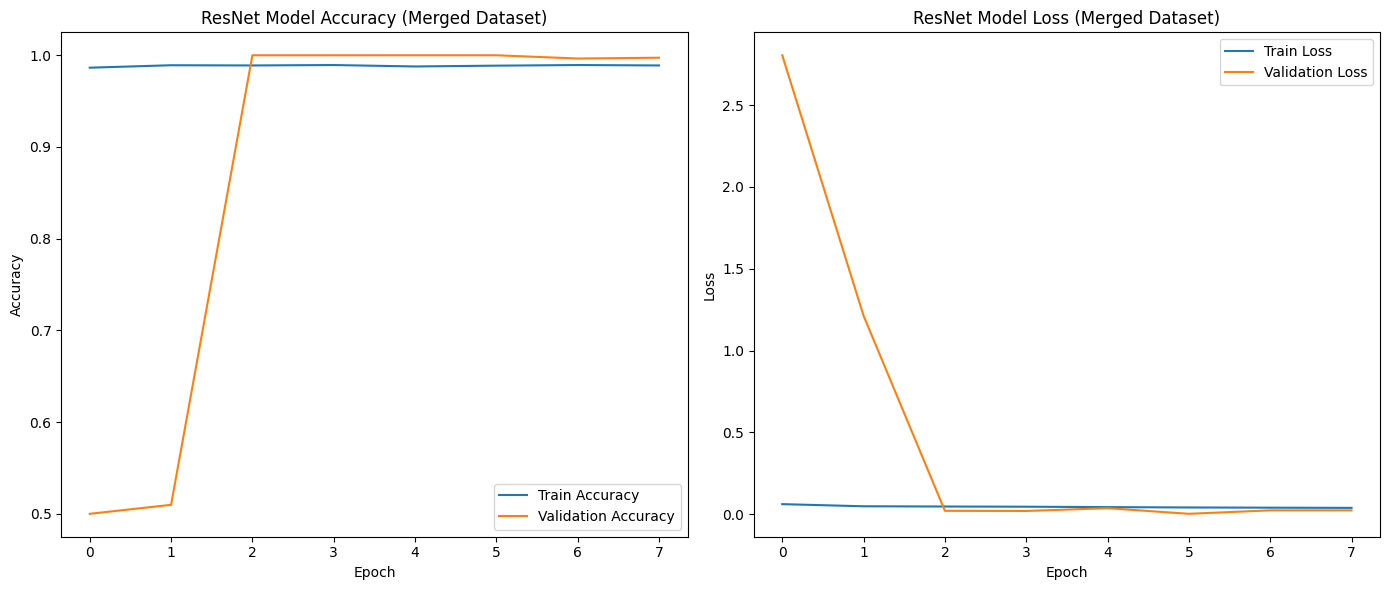

In [57]:
import matplotlib.pyplot as plt

# 3. Plot Training History
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history_resnet_merged.history['accuracy'], label='Train Accuracy')
plt.plot(history_resnet_merged.history['val_accuracy'], label='Validation Accuracy')
plt.title('ResNet Model Accuracy (Merged Dataset)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_resnet_merged.history['loss'], label='Train Loss')
plt.plot(history_resnet_merged.history['val_loss'], label='Validation Loss')
plt.title('ResNet Model Loss (Merged Dataset)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [58]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# 4. Evaluate the Model
print("\n--- Evaluating ResNet Model Performance ---")
loss_resnet_merged, acc_resnet_merged = model_resnet.evaluate(val_data_merged)
print(f"Validation Accuracy (ResNet Merged): {acc_resnet_merged:.4f}")
print(f"Validation Loss (ResNet Merged): {loss_resnet_merged:.4f}")

val_data_merged.reset()
predictions_resnet_merged = model_resnet.predict(val_data_merged)
predicted_classes_resnet_merged = (predictions_resnet_merged > 0.5).astype(int)

true_classes_resnet_merged = val_data_merged.classes


--- Evaluating ResNet Model Performance ---
71/71 ━━━━━━━━━━━━━━━━━━━━ 20s 289ms/step - accuracy: 1.0000 - loss: 0.0036
Validation Accuracy (ResNet Merged): 1.0000
Validation Loss (ResNet Merged): 0.0036
71/71 ━━━━━━━━━━━━━━━━━━━━ 18s 249ms/step



ResNet Confusion Matrix (Merged Dataset):
[[286 276]
 [276 286]]


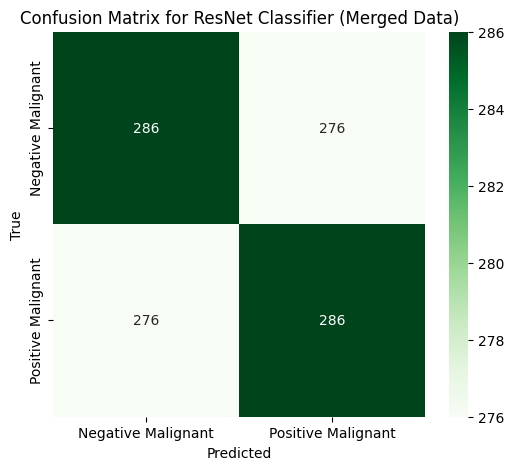


ResNet Classification Report (Merged Dataset):
                    precision    recall  f1-score   support

negative_malignant       0.51      0.51      0.51       562
positive_malignant       0.51      0.51      0.51       562

          accuracy                           0.51      1124
         macro avg       0.51      0.51      0.51      1124
      weighted avg       0.51      0.51      0.51      1124



In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_resnet_merged = confusion_matrix(true_classes_resnet_merged, predicted_classes_resnet_merged)
print("\nResNet Confusion Matrix (Merged Dataset):")
print(cm_resnet_merged)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_resnet_merged, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative Malignant', 'Positive Malignant'],
            yticklabels=['Negative Malignant', 'Positive Malignant'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for ResNet Classifier (Merged Data)')
plt.show()

print("\nResNet Classification Report (Merged Dataset):")
print(classification_report(true_classes_resnet_merged, predicted_classes_resnet_merged, target_names=['negative_malignant', 'positive_malignant']))

In [60]:
import joblib
import os

# Define paths to save the models
model_save_dir = "/content/saved_models"
os.makedirs(model_save_dir, exist_ok=True)

rf_model_path = os.path.join(model_save_dir, "random_forest_model.joblib")
nb_model_path = os.path.join(model_save_dir, "naive_bayes_model.joblib")

# --- Save Random Forest Model ---
print(f"Saving Random Forest model to {rf_model_path}...")
joblib.dump(rf_classifier_merged, rf_model_path)
print("Random Forest model saved.")

# --- Save Naive Bayes Model ---
print(f"Saving Naive Bayes model to {nb_model_path}...")
joblib.dump(nb_classifier_merged, nb_model_path)
print("Naive Bayes model saved.")

print("\n--- Demonstrating Loading and Prediction ---")

# --- Load Random Forest Model and Predict ---
print(f"Loading Random Forest model from {rf_model_path}...")
loaded_rf_model = joblib.load(rf_model_path)
print("Random Forest model loaded.")

# Make predictions using the loaded RF model
# Assuming X_test_flat is available from previous cells
if 'X_test_flat' in locals():
    sample_rf_prediction = loaded_rf_model.predict(X_test_flat[:5])
    print(f"Sample RF predictions on first 5 test samples: {sample_rf_prediction}")
else:
    print("X_test_flat not found, cannot demonstrate RF prediction.")

# --- Load Naive Bayes Model and Predict ---
print(f"\nLoading Naive Bayes model from {nb_model_path}...")
loaded_nb_model = joblib.load(nb_model_path)
print("Naive Bayes model loaded.")

# Make predictions using the loaded NB model
# Assuming X_test_flat is available from previous cells
if 'X_test_flat' in locals():
    sample_nb_prediction = loaded_nb_model.predict(X_test_flat[:5])
    print(f"Sample NB predictions on first 5 test samples: {sample_nb_prediction}")
else:
    print("X_test_flat not found, cannot demonstrate NB prediction.")


Saving Random Forest model to /content/saved_models/random_forest_model.joblib...
Random Forest model saved.
Saving Naive Bayes model to /content/saved_models/naive_bayes_model.joblib...
Naive Bayes model saved.

--- Demonstrating Loading and Prediction ---
Loading Random Forest model from /content/saved_models/random_forest_model.joblib...
Random Forest model loaded.
Sample RF predictions on first 5 test samples: [1 1 1 0 1]

Loading Naive Bayes model from /content/saved_models/naive_bayes_model.joblib...
Naive Bayes model loaded.
Sample NB predictions on first 5 test samples: [1 1 1 0 1]


In [61]:
import shutil
from google.colab import files
import os

# Define the directory where models are saved
model_save_dir = "/content/saved_models"
output_zip_filename = "saved_models.zip"

# Create a zip archive of the saved_models directory
print(f"Creating zip archive of models from {model_save_dir}...")
shutil.make_archive(os.path.join("/content", output_zip_filename.split('.')[0]), 'zip', model_save_dir)
print(f"Archive '{output_zip_filename}' created.")

# Offer the zip file for download
print(f"\nDownloading {output_zip_filename}...")
files.download(os.path.join("/content", output_zip_filename))
print("Download initiated.")

Creating zip archive of models from /content/saved_models...
Archive 'saved_models.zip' created.



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download initiated.
